# Análise exploratória da série temporal de tráfego do PTT/IX

Este notebook apresenta uma caracterização exploratória do comportamento típico do tráfego do PTT/IX utilizando a base previamente preparada no notebook **00_data_preparation**.

O foco desta análise está na evolução do nível de tráfego ao longo do tempo, por meio de estatísticas descritivas, padrões sazonais e comportamento temporal médio da série.

Neste notebook são realizadas as seguintes análises:

- evolução anual do nível de tráfego;
- série temporal diária com intervalo de confiança de 95%;
- padrões sazonais ao longo do ano;
- comportamento por dia da semana;
- comparação entre dias úteis e fins de semana.

A análise dos **picos de tráfego**, mais diretamente relacionada ao planejamento da capacidade da infraestrutura do IX, é apresentada no notebook **02_peak_analysis**.

## Lendo dados

In [1]:
import sys
print(sys.executable)

import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/cristiane/git/mba-ai-usp/monograph/.venv/bin/python


In [2]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd().parent

arquivo_serie_csv = (
    base_dir / "data" / "processed" / "serie_temporal_filtrada_gbps.csv"
)

arquivo_resumo_csv = (
    base_dir / "data" / "processed" / "resumo_anual_filtrado_gbps.csv"
)

df_filtrado = pd.read_csv(
    arquivo_serie_csv,
    parse_dates=["datahora"]
)

resumo = pd.read_csv(
    arquivo_resumo_csv,
    index_col=0
)

df_filtrado.head()

,datahora,total_bps,year,total_gbps
0,2008-01-01 00:02:29,NaN,2008,NaN
1,2008-01-01 00:07:29,NaN,2008,NaN
2,2008-01-01 00:12:29,NaN,2008,NaN
3,2008-01-01 00:17:29,NaN,2008,NaN
4,2008-01-01 00:22:29,NaN,2008,NaN


## 12. Série temporal total com média diária e intervalo de confiança

Como a série original tem resolução de 5 minutos, é útil agregá-la por dia.

Para cada dia, serão calculados:

- média diária do tráfego total em Gbps;
- desvio padrão;
- número de observações;
- intervalo de confiança aproximado de 95%.

In [3]:
df_diario = df_filtrado.copy()
df_diario["data"] = df_diario["datahora"].dt.floor("D")

media_diaria = (
    df_diario.groupby("data")["total_gbps"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

media_diaria["ci_lower"] = media_diaria["mean"] - 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))
media_diaria["ci_upper"] = media_diaria["mean"] + 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))

media_diaria = media_diaria.rename(columns={
    "mean": "media_gbps",
    "std": "desvio_gbps",
    "count": "n_obs"
})

media_diaria.head()

,data,media_gbps,desvio_gbps,n_obs,ci_lower,ci_upper
0,2008-01-01,NaN,NaN,0,NaN,NaN
1,2008-01-02,NaN,NaN,0,NaN,NaN
2,2008-01-03,NaN,NaN,0,NaN,NaN
3,2008-01-04,NaN,NaN,0,NaN,NaN
4,2008-01-05,NaN,NaN,0,NaN,NaN


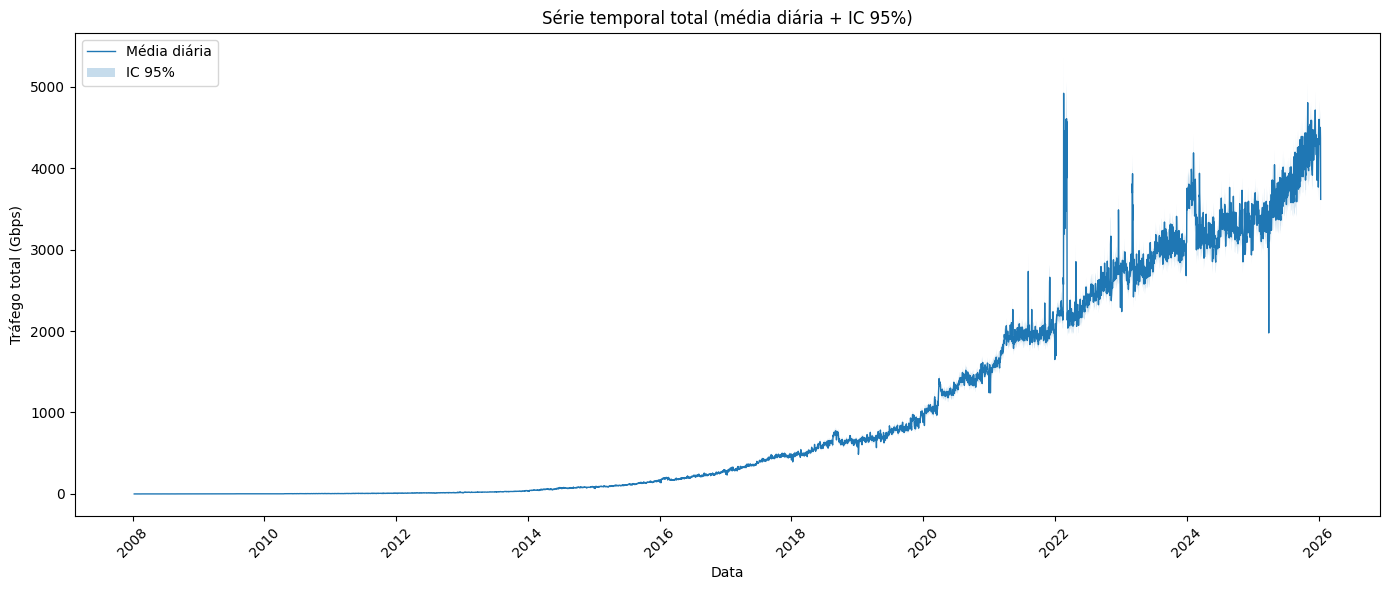

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    label="Média diária",
    linewidth=1
)

plt.fill_between(
    media_diaria["data"],
    media_diaria["ci_lower"],
    media_diaria["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total (média diária + IC 95%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

O uso da média diária reduz o ruído de curtíssimo prazo e facilita a visualização da tendência de longo prazo.

O intervalo de confiança de 95% resume a variabilidade intra-dia:

- faixas mais estreitas sugerem maior estabilidade;
- faixas mais largas sugerem maior dispersão das medições ao longo do dia.

## 14. Média diária suavizada (opcional)

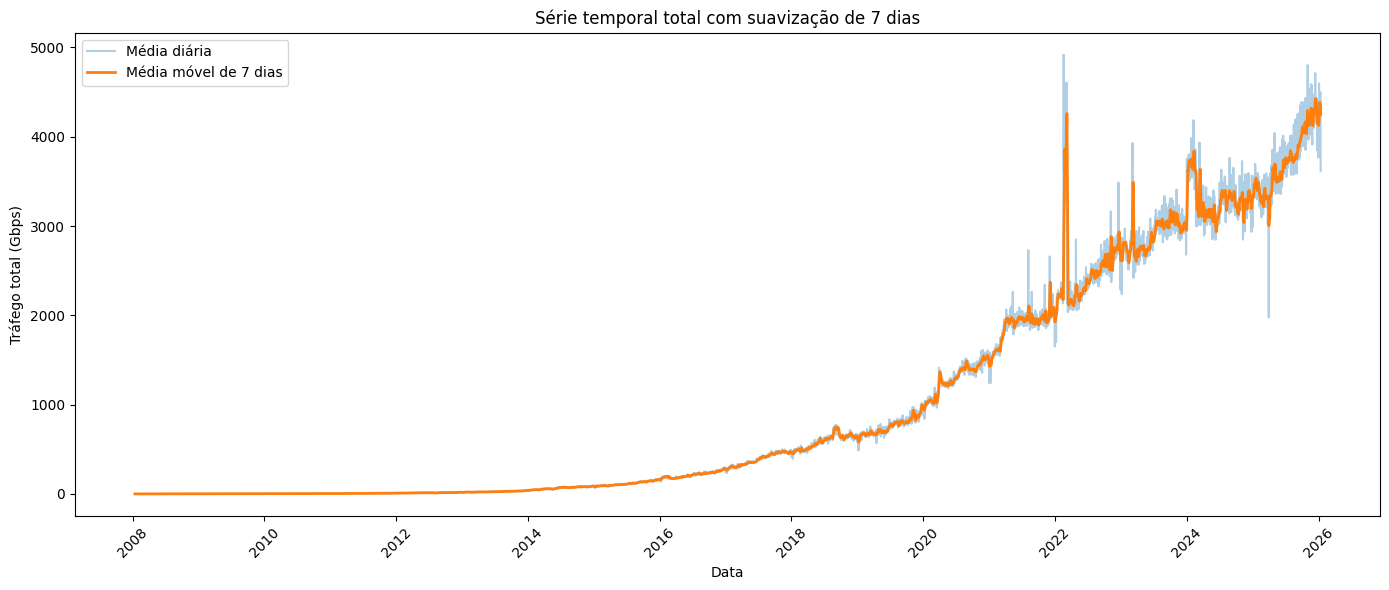

In [5]:
media_diaria["media_movel_7d"] = media_diaria["media_gbps"].rolling(7).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    alpha=0.35,
    label="Média diária"
)

plt.plot(
    media_diaria["data"],
    media_diaria["media_movel_7d"],
    linewidth=2,
    label="Média móvel de 7 dias"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total com suavização de 7 dias")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

A média móvel de 7 dias ajuda a destacar a tendência geral da série, reduzindo oscilações diárias.

## 15. Evolução intra-anual com média diária em Gbps

In [6]:
df_plot = df_filtrado.copy()
df_plot["dia_ano"] = df_plot["datahora"].dt.dayofyear

media_intra_anual = (
    df_plot.groupby(["year", "dia_ano"])["total_gbps"]
    .mean()
    .reset_index()
)

media_intra_anual.head()

,year,dia_ano,total_gbps
0,2008,1,NaN
1,2008,2,NaN
2,2008,3,NaN
3,2008,4,NaN
4,2008,5,NaN


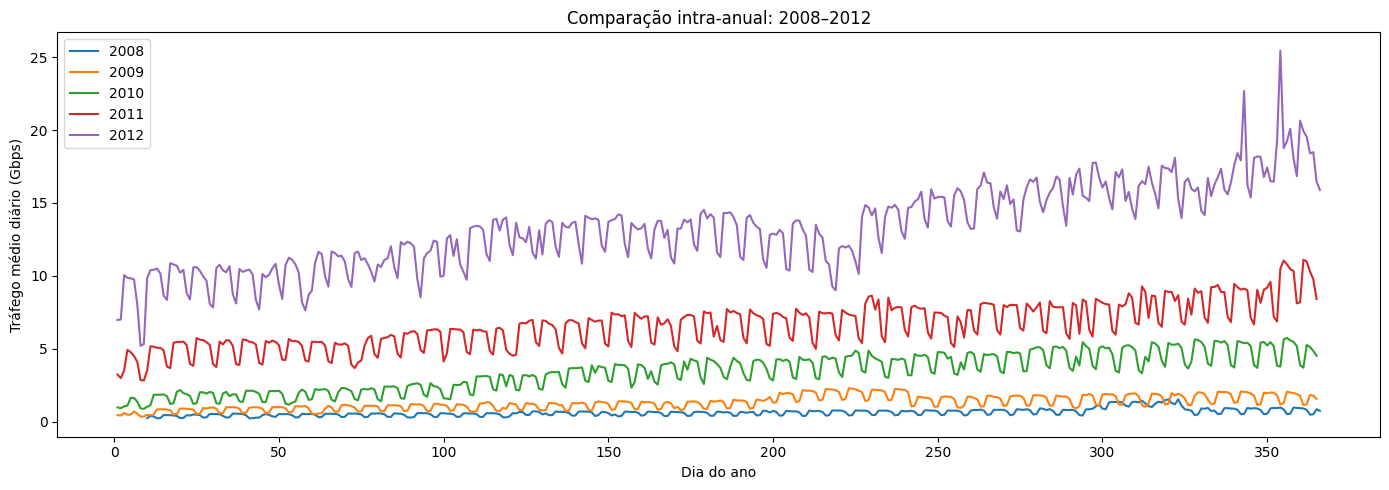

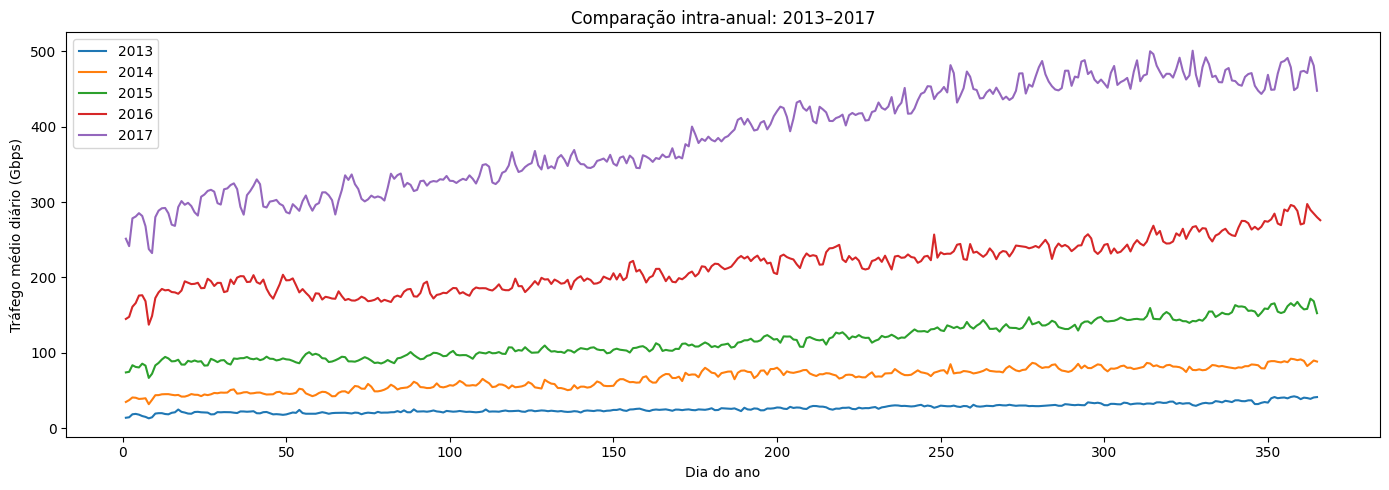

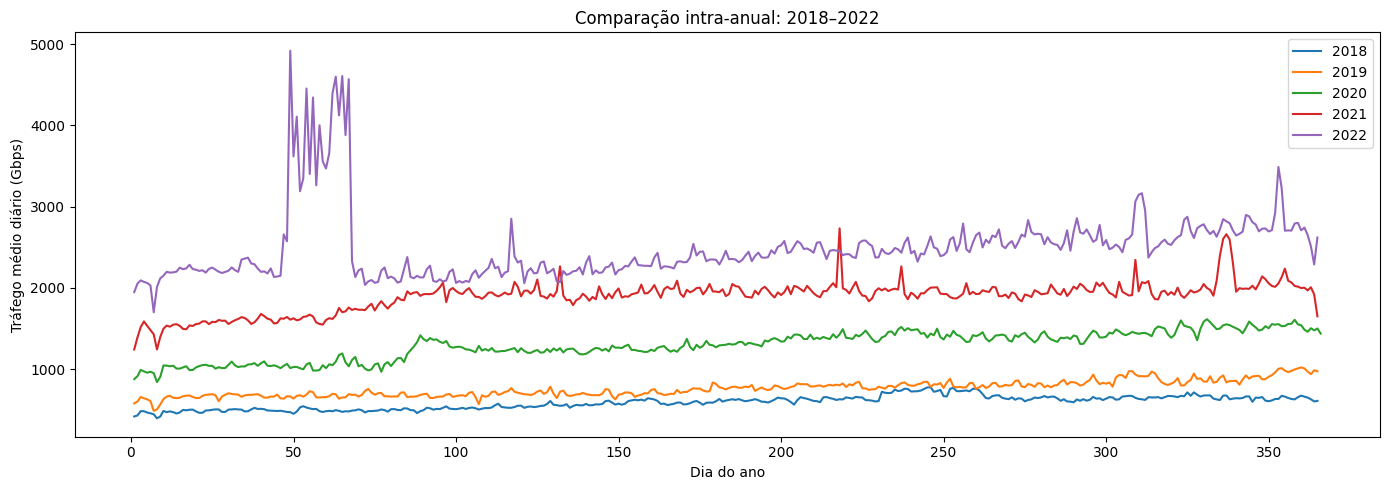

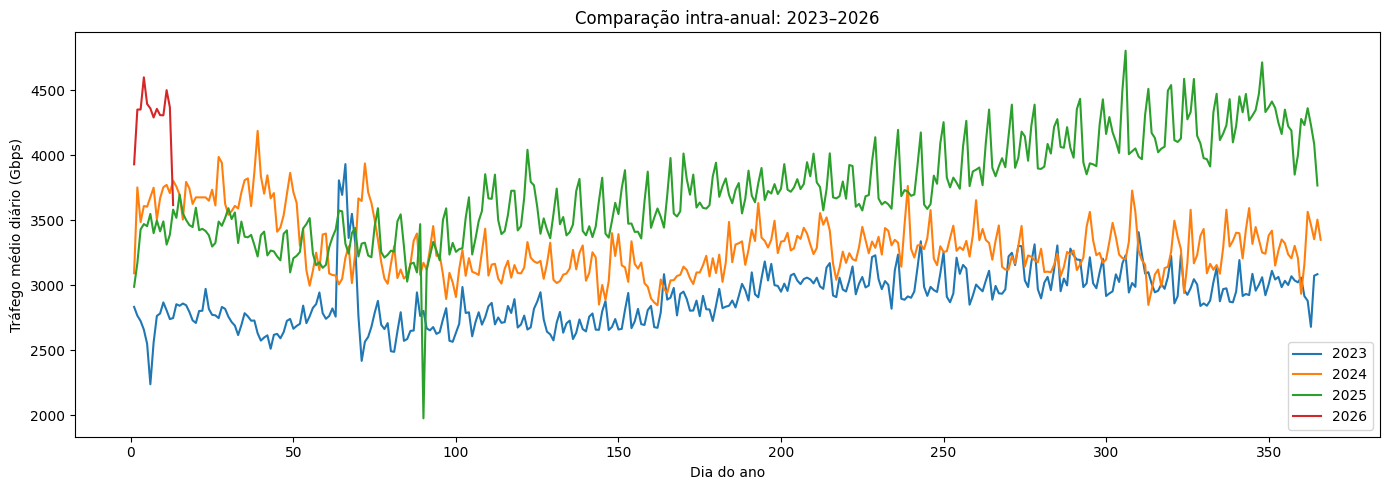

In [7]:
anos = sorted(media_intra_anual["year"].unique())
blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(14, 5))
    for ano in bloco:
        grupo = media_intra_anual[media_intra_anual["year"] == ano]
        plt.plot(grupo["dia_ano"], grupo["total_gbps"], label=str(ano))
    plt.xlabel("Dia do ano")
    plt.ylabel("Tráfego médio diário (Gbps)")
    plt.title(f"Comparação intra-anual: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretação

Esses gráficos permitem observar se há crescimento dentro do próprio ano, além de possíveis padrões sazonais ou mudanças de regime entre períodos.

## 16. Análise por dia da semana

Agora a análise passa a considerar o comportamento do tráfego total ao longo da semana, usando apenas os dados filtrados.

In [8]:
df_filtrado["weekday"] = df_filtrado["datahora"].dt.weekday

mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

resumo_weekday_total = (
    df_filtrado.groupby("weekday")["total_gbps"]
    .mean()
    .reset_index(name="media_total_gbps")
)

resumo_weekday_total["dia"] = resumo_weekday_total["weekday"].map(mapa_dias)
resumo_weekday_total["media_total_gbps"] = resumo_weekday_total["media_total_gbps"].round(3)

resumo_weekday_total

,weekday,media_total_gbps,dia
0,0,988.636,Seg
1,1,980.817,Ter
2,2,982.819,Qua
3,3,987.595,Qui
4,4,981.509,Sex
5,5,985.606,Sáb
6,6,1000.453,Dom


### Observação metodológica

A média agregada de todos os anos pode ser enviesada, porque os anos mais recentes têm nível de tráfego muito maior que os anos antigos. Por isso, além do resumo geral, também é útil comparar o padrão semanal por blocos temporais.

## 17. Padrão semanal por blocos de anos com média diária

In [9]:
for bloco in [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]:
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")
    media["dia"] = media["weekday"].map(mapa_dias)
    media["media_total_gbps"] = media["media_total_gbps"].round(3)

    print(f"\nPeríodo {bloco}:")
    print(media[["weekday", "dia", "media_total_gbps"]])


Período (2008, 2012):
   weekday  dia  media_total_gbps
0        0  Seg             4.160
1        1  Ter             5.430
2        2  Qua             5.430
3        3  Qui             5.402
4        4  Sex             5.366
5        5  Sáb             5.277
6        6  Dom             4.326

Período (2013, 2017):
   weekday  dia  media_total_gbps
0        0  Seg           159.877
1        1  Ter           160.722
2        2  Qua           161.500
3        3  Qui           162.075
4        4  Sex           162.672
5        5  Sáb           163.739
6        6  Dom           162.505

Período (2018, 2022):
   weekday  dia  media_total_gbps
0        0  Seg          1398.496
1        1  Ter          1394.796
2        2  Qua          1400.202
3        3  Qui          1393.564
4        4  Sex          1412.419
5        5  Sáb          1404.211
6        6  Dom          1400.817

Período (2023, 2026):
   weekday  dia  media_total_gbps
0        0  Seg          3328.940
1        1  Ter         

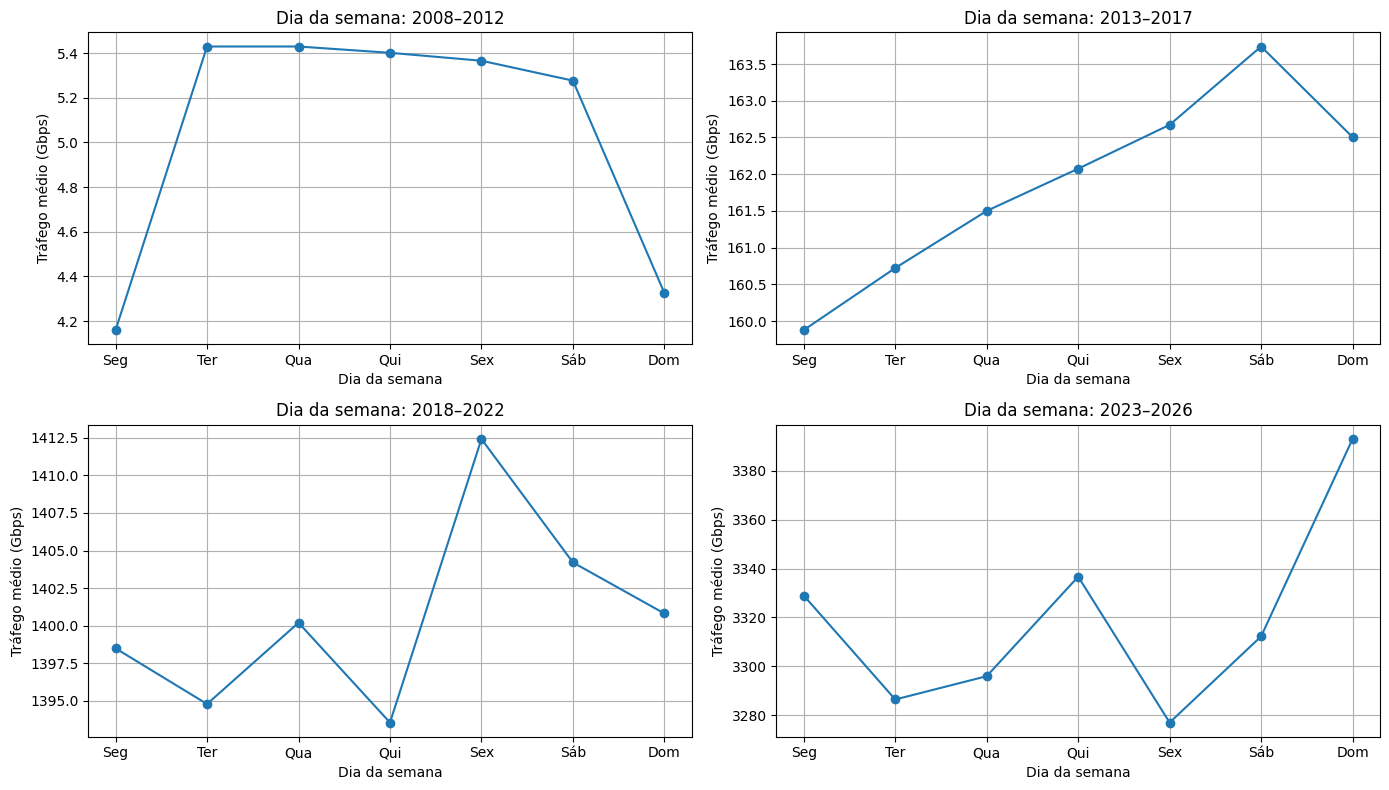

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")

    ax.plot(media["weekday"], media["media_total_gbps"], marker="o")
    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Tráfego médio (Gbps)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretação

Embora seja possível observar mudanças no dia da semana associado ao maior tráfego médio ao longo da série histórica, a magnitude dessas variações permanece relativamente pequena dentro de cada período. Em geral, a diferença entre o dia de maior e o de menor tráfego médio corresponde a poucos pontos percentuais do volume médio semanal, indicando que o crescimento de longo prazo da demanda é muito mais expressivo do que as oscilações associadas ao dia da semana.

## 19. Comparação entre dias úteis e fim de semana com média diária

Nesta etapa, a semana é resumida em dois grupos:

- **dias úteis**: segunda a sexta;
- **fim de semana**: sábado e domingo.

Interpretação

Essa razão resume o padrão semanal em uma única métrica:

- valores **abaixo de 1** indicam maior tráfego em dias úteis;
- valores **próximos de 1** indicam uniformização do padrão semanal;
- valores **acima de 1** sugerem maior intensidade relativa de tráfego no fim de semana.

Essa análise é útil para detectar mudanças estruturais no perfil de uso da rede.

In [11]:
df_filtrado["is_weekend"] = df_filtrado["weekday"] >= 5

comparacao_weekend = (
    df_filtrado.groupby(["year", "is_weekend"])["total_gbps"]
    .mean()
    .reset_index()
)

comparacao_weekend["grupo"] = comparacao_weekend["is_weekend"].map({
    False: "dias_uteis",
    True: "fim_de_semana"
})

comparacao_weekend_pivot = comparacao_weekend.pivot(
    index="year",
    columns="grupo",
    values="total_gbps"
)

comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"] = (
    comparacao_weekend_pivot["fim_de_semana"] /
    comparacao_weekend_pivot["dias_uteis"]
)

comparacao_weekend_pivot = comparacao_weekend_pivot.round(3)

comparacao_weekend_pivot

grupo,dias_uteis,fim_de_semana,razao_fim_semana_sobre_uteis
year,,,
2008,0.665,0.547,0.822
2009,1.366,1.130,0.828
2010,3.520,3.118,0.886
2011,6.754,6.169,0.913
2012,13.389,12.902,0.964
2013,26.354,26.569,1.008
2014,65.378,67.362,1.030
2015,115.913,116.954,1.009
2016,214.733,214.420,0.999


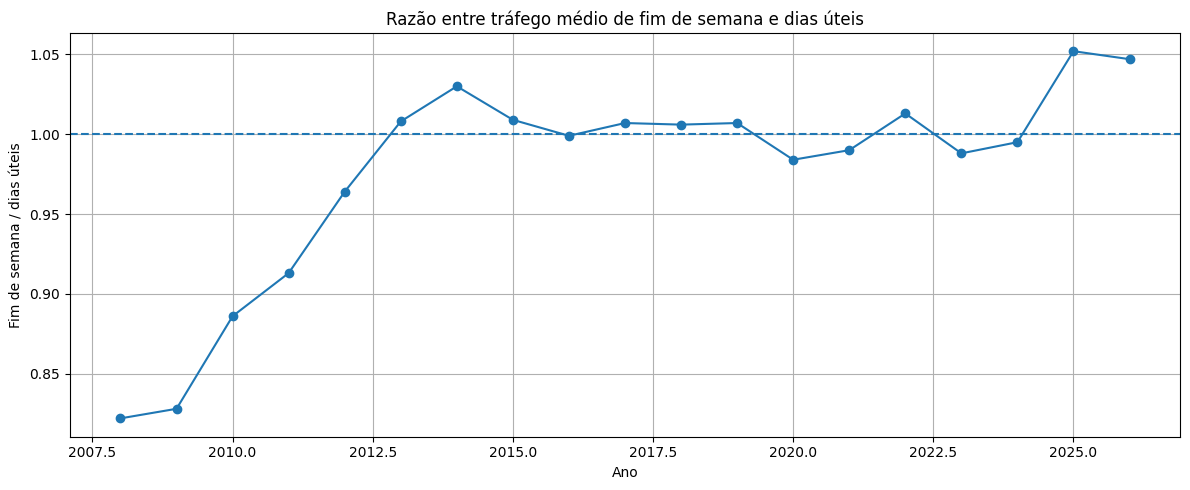

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparacao_weekend_pivot.index,
    comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"],
    marker="o"
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Ano")
plt.ylabel("Fim de semana / dias úteis")
plt.title("Razão entre tráfego médio de fim de semana e dias úteis")
plt.grid(True)
plt.tight_layout()
plt.show()

## 21. Salvando os resumos de weekday e fim de semana

In [13]:
#resumo_weekday_total.to_csv(arquivo_weekday_csv, index=False)
#comparacao_weekend_pivot.to_csv(arquivo_weekend_csv)

#print("Resumo por dia da semana salvo em:", arquivo_weekday_csv)
#print("Comparação dias úteis vs fim de semana salva em:", arquivo_weekend_csv)

In [14]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd().parent

arquivo_serie_csv = (
    base_dir / "data" / "processed" / "serie_temporal_filtrada_gbps.csv"
)

arquivo_resumo_csv = (
    base_dir / "data" / "processed" / "resumo_anual_filtrado_gbps.csv"
)

df_filtrado = pd.read_csv(
    arquivo_serie_csv,
    parse_dates=["datahora"]
)

resumo = pd.read_csv(
    arquivo_resumo_csv,
    index_col=0
)

df_filtrado.head()

,datahora,total_bps,year,total_gbps
0,2008-01-01 00:02:29,NaN,2008,NaN
1,2008-01-01 00:07:29,NaN,2008,NaN
2,2008-01-01 00:12:29,NaN,2008,NaN
3,2008-01-01 00:17:29,NaN,2008,NaN
4,2008-01-01 00:22:29,NaN,2008,NaN
